In [48]:
!pip install pennylane imbalanced-learn pyswarms xgboost --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, time
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import OneClassSVM, SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, precision_recall_curve
)
import pennylane as qml
from pennylane import numpy as pnp

print("All imports done!")
print("PennyLane version:", qml.__version__)

All imports done!
PennyLane version: 0.44.1


In [49]:
import os

csv_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == 'creditcard.csv':
            csv_path = os.path.join(dirname, filename)

print("Found at:", csv_path)
df = pd.read_csv(csv_path)
print("Shape:", df.shape)
print("Fraud %:", round(df['Class'].mean()*100, 4))
df.head()

Found at: /kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv
Shape: (284807, 31)
Fraud %: 0.1727


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


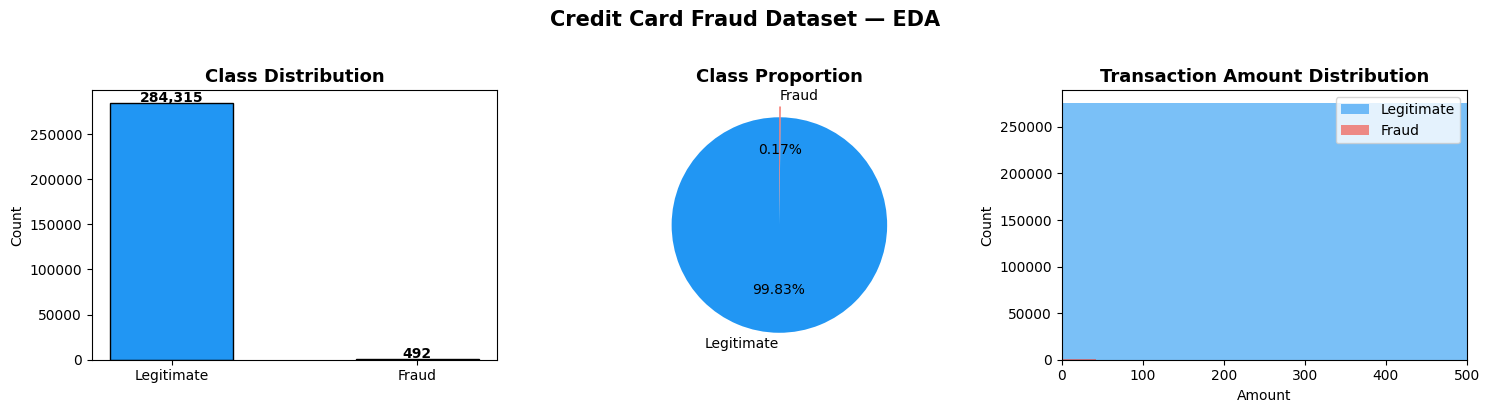

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

counts = df['Class'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], counts.values,
            color=['#2196F3', '#F44336'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.2f%%', colors=['#2196F3', '#F44336'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

axes[2].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6,
             color='#2196F3', label='Legitimate')
axes[2].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.6,
             color='#F44336', label='Fraud')
axes[2].set_title('Transaction Amount Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Amount')
axes[2].set_ylabel('Count')
axes[2].legend()
axes[2].set_xlim(0, 500)

plt.suptitle('Credit Card Fraud Dataset — EDA',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

After dedup: (283726, 31)
X_train: (756, 30) | class dist: [378 378]
X_test : (190, 30) | class dist: [95 95]


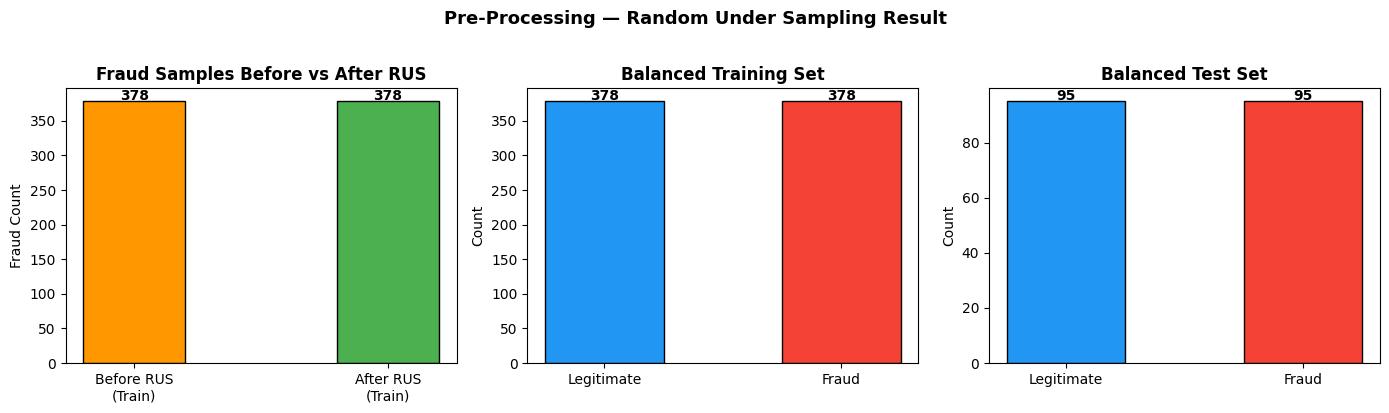

In [51]:
df_clean = df.drop_duplicates().copy()
print("After dedup:", df_clean.shape)

scaler = MinMaxScaler()
df_clean[['Time', 'Amount']] = scaler.fit_transform(df_clean[['Time', 'Amount']])

X = df_clean.drop('Class', axis=1).values
y = df_clean['Class'].values
feature_names = df_clean.drop('Class', axis=1).columns.tolist()

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rus_train = RandomUnderSampler(random_state=42)
X_train, y_train = rus_train.fit_resample(X_train_raw, y_train_raw)

rus_test = RandomUnderSampler(random_state=42)
X_test, y_test = rus_test.fit_resample(X_test_raw, y_test_raw)

print("X_train:", X_train.shape, "| class dist:", np.bincount(y_train))
print("X_test :", X_test.shape,  "| class dist:", np.bincount(y_test))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(['Before RUS\n(Train)', 'After RUS\n(Train)'],
            [y_train_raw.sum(), y_train.sum()],
            color=['#FF9800', '#4CAF50'], width=0.4, edgecolor='black')
axes[0].set_title('Fraud Samples Before vs After RUS', fontweight='bold')
axes[0].set_ylabel('Fraud Count')
for i, v in enumerate([y_train_raw.sum(), y_train.sum()]):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].bar(['Legitimate', 'Fraud'], np.bincount(y_train),
            color=['#2196F3', '#F44336'], edgecolor='black', width=0.5)
axes[1].set_title('Balanced Training Set', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(np.bincount(y_train)):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[2].bar(['Legitimate', 'Fraud'], np.bincount(y_test),
            color=['#2196F3', '#F44336'], edgecolor='black', width=0.5)
axes[2].set_title('Balanced Test Set', fontweight='bold')
axes[2].set_ylabel('Count')
for i, v in enumerate(np.bincount(y_test)):
    axes[2].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.suptitle('Pre-Processing — Random Under Sampling Result',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

2026-03-14 12:38:21,496 - pyswarms.single.global_best - INFO - Optimize for 20 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


Running PSO...


pyswarms.single.global_best: 100%|██████████|20/20, best_cost=0.0892
2026-03-14 12:38:28,133 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.08923423423423421, best pos: [0.27234944 0.73973171 0.95869212 0.29142078 0.84628018 0.95820389
 0.40607348 0.44951483 0.65559478 0.1621879  0.01850473 0.88122329
 0.76004409 0.26676337 0.76884337 0.35244817 0.36214321 0.81752876
 0.23273217 0.76859263 0.03001033 0.48196819 0.9507344  0.69886434
 0.14643756 0.41445863 0.55546182 0.37610513 0.33754671 0.08383699]


Features selected: 13 / 30
Selected: ['V1', 'V2', 'V4', 'V5', 'V8', 'V11', 'V12', 'V14', 'V17', 'V19', 'V22', 'V23', 'V26']


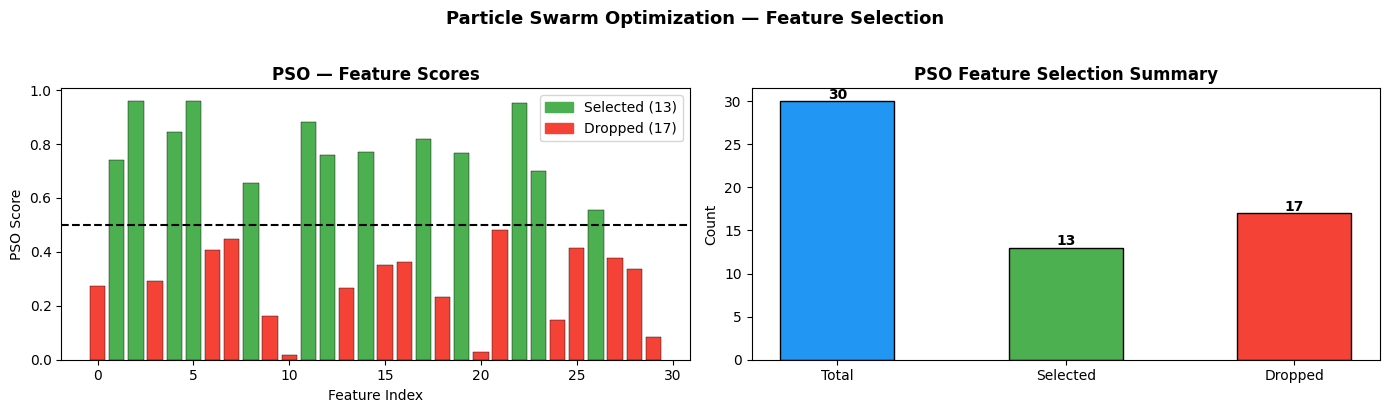

In [52]:
import pyswarms as ps

N_FEATURES = X_train.shape[1]

X_pso_tr, X_pso_val, y_pso_tr, y_pso_val = train_test_split(
    X_train[:3000], y_train[:3000],
    test_size=0.2, random_state=42,
    stratify=y_train[:3000]
)

def pso_fitness(particles):
    costs = []
    for particle in particles:
        mask = particle > 0.5
        if mask.sum() == 0:
            costs.append(1.0)
            continue
        clf = RandomForestClassifier(n_estimators=5, random_state=42, n_jobs=-1)
        clf.fit(X_pso_tr[:, mask], y_pso_tr)
        preds = clf.predict(X_pso_val[:, mask])
        score = f1_score(y_pso_val, preds, zero_division=0)
        penalty = mask.sum() / N_FEATURES * 0.05
        costs.append(1.0 - score + penalty)
    return np.array(costs)

print("Running PSO...")
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
optimizer = ps.single.GlobalBestPSO(
    n_particles=10, dimensions=N_FEATURES, options=options,
    bounds=(np.zeros(N_FEATURES), np.ones(N_FEATURES))
)
cost, best_pos = optimizer.optimize(pso_fitness, iters=20, verbose=True)

pso_mask = best_pos > 0.5
selected_features = [feature_names[i] for i in range(N_FEATURES) if pso_mask[i]]
print("Features selected:", pso_mask.sum(), "/", N_FEATURES)
print("Selected:", selected_features)

X_train_pso = X_train[:, pso_mask]
X_test_pso  = X_test[:, pso_mask]

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ['#4CAF50' if m else '#F44336' for m in pso_mask]
axes[0].bar(range(N_FEATURES), best_pos, color=colors,
            edgecolor='black', linewidth=0.3)
axes[0].axhline(0.5, color='black', linestyle='--',
                linewidth=1.5, label='Threshold = 0.5')
axes[0].set_title('PSO — Feature Scores', fontweight='bold')
axes[0].set_xlabel('Feature Index')
axes[0].set_ylabel('PSO Score')
selected_patch = mpatches.Patch(color='#4CAF50', label=f'Selected ({pso_mask.sum()})')
dropped_patch  = mpatches.Patch(color='#F44336', label=f'Dropped ({(~pso_mask).sum()})')
axes[0].legend(handles=[selected_patch, dropped_patch])

axes[1].bar(['Total', 'Selected', 'Dropped'],
            [N_FEATURES, pso_mask.sum(), (~pso_mask).sum()],
            color=['#2196F3', '#4CAF50', '#F44336'],
            edgecolor='black', width=0.5)
axes[1].set_title('PSO Feature Selection Summary', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate([N_FEATURES, pso_mask.sum(), (~pso_mask).sum()]):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

plt.suptitle('Particle Swarm Optimization — Feature Selection',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [53]:
results = {}

# ── Random Forest ──────────────────────────────────────────────
print("Training Random Forest...")
t0 = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_pso, y_train)
y_pred_rf  = rf.predict(X_test_pso)
y_proba_rf = rf.predict_proba(X_test_pso)[:, 1]
results['Random Forest'] = {'pred': y_pred_rf, 'proba': y_proba_rf}
print(f"Done in {round(time.time()-t0, 2)}s")
print(classification_report(y_test, y_pred_rf,
      target_names=['Legitimate', 'Fraud']))

# ── XGBoost ────────────────────────────────────────────────────
print("Training XGBoost...")
t0 = time.time()
xgb = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                     random_state=42, eval_metric='logloss', verbosity=0)
xgb.fit(X_train_pso, y_train)
y_pred_xgb  = xgb.predict(X_test_pso)
y_proba_xgb = xgb.predict_proba(X_test_pso)[:, 1]
results['XGBoost'] = {'pred': y_pred_xgb, 'proba': y_proba_xgb}
print(f"Done in {round(time.time()-t0, 2)}s")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Legitimate', 'Fraud']))

# ── One-Class SVM ──────────────────────────────────────────────
print("Training One-Class SVM...")
t0 = time.time()
X_legit          = X_train_pso[y_train == 0]
ocsvm            = OneClassSVM(kernel='rbf', nu=0.05, gamma='auto')
ocsvm.fit(X_legit)
y_pred_ocsvm_raw = ocsvm.predict(X_test_pso)
y_pred_ocsvm     = np.where(y_pred_ocsvm_raw == -1, 1, 0)
y_score_ocsvm    = -ocsvm.decision_function(X_test_pso)
y_score_ocsvm    = (y_score_ocsvm - y_score_ocsvm.min()) / \
                   (y_score_ocsvm.max() - y_score_ocsvm.min())
results['OC-SVM'] = {'pred': y_pred_ocsvm, 'proba': y_score_ocsvm}
print(f"Done in {round(time.time()-t0, 2)}s")
print(classification_report(y_test, y_pred_ocsvm,
      target_names=['Legitimate', 'Fraud']))

Training Random Forest...
Done in 0.29s
              precision    recall  f1-score   support

  Legitimate       0.87      0.96      0.91        95
       Fraud       0.95      0.85      0.90        95

    accuracy                           0.91       190
   macro avg       0.91      0.91      0.91       190
weighted avg       0.91      0.91      0.90       190

Training XGBoost...
Done in 0.08s
              precision    recall  f1-score   support

  Legitimate       0.88      0.97      0.92        95
       Fraud       0.96      0.86      0.91        95

    accuracy                           0.92       190
   macro avg       0.92      0.92      0.92       190
weighted avg       0.92      0.92      0.92       190

Training One-Class SVM...
Done in 0.01s
              precision    recall  f1-score   support

  Legitimate       0.87      0.82      0.84        95
       Fraud       0.83      0.87      0.85        95

    accuracy                           0.85       190
   macro avg  

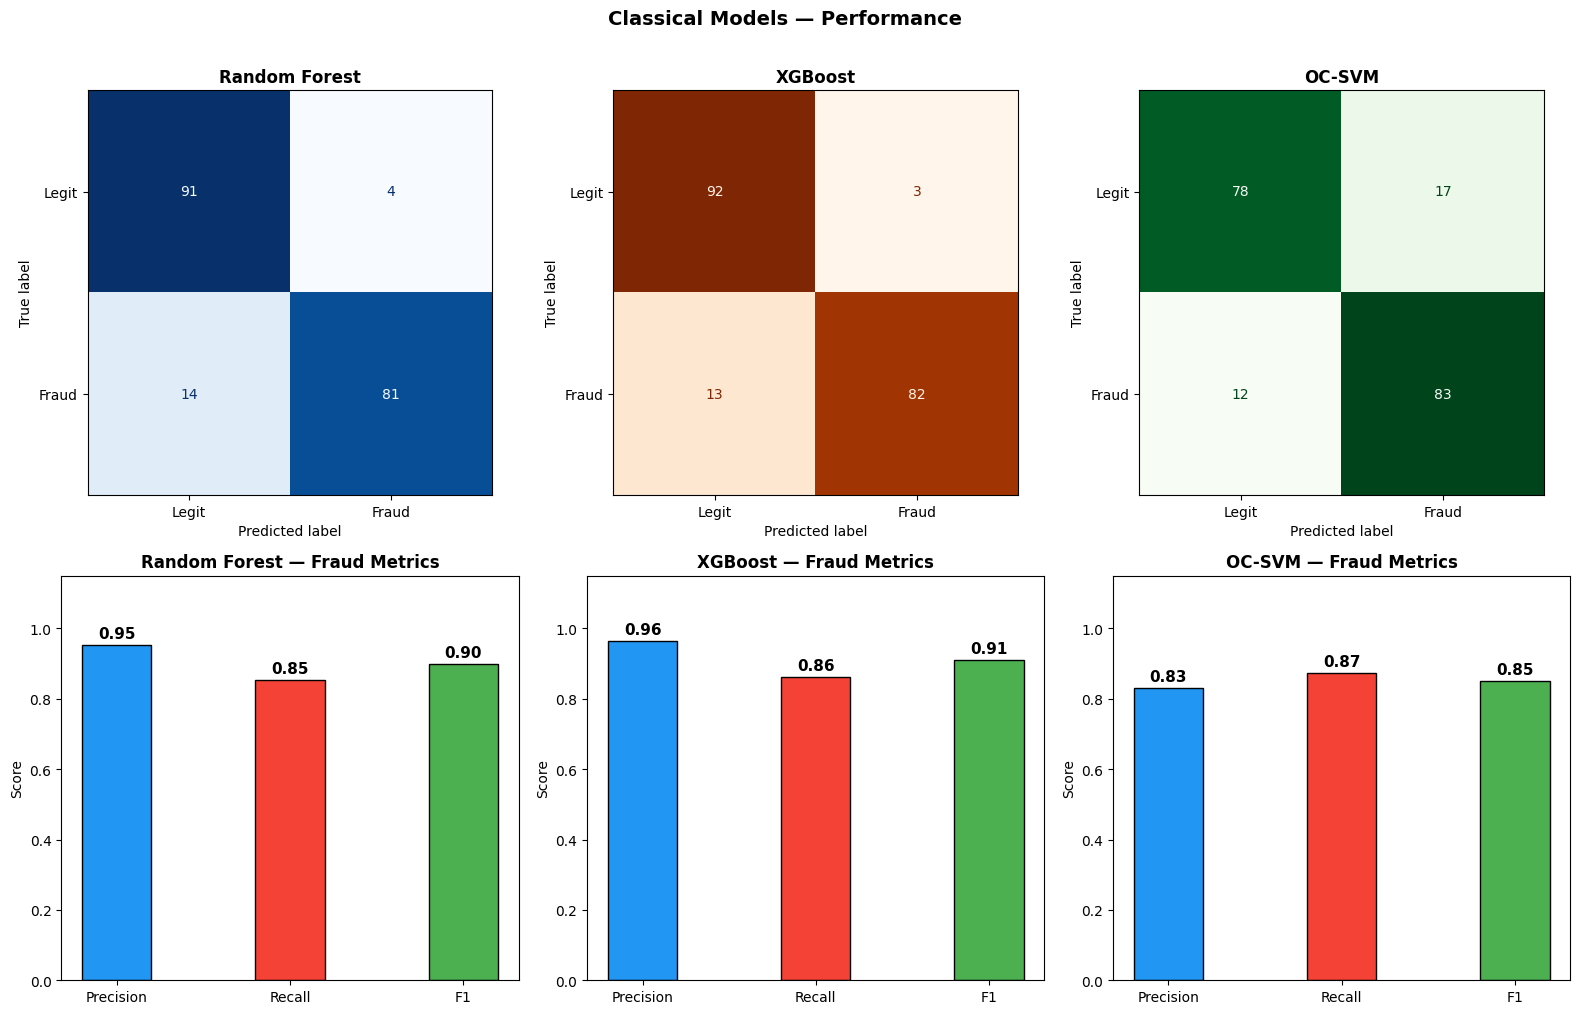

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cms_colors = ['Blues', 'Oranges', 'Greens']

# Row 1 — Confusion matrices
for i, (name, res) in enumerate(results.items()):
    cm   = confusion_matrix(y_test, res['pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=axes[0][i], colorbar=False, cmap=cms_colors[i])
    axes[0][i].set_title(f'{name}', fontweight='bold', fontsize=12)

# Row 2 — Metric bars per model
bar_colors = ['#2196F3', '#F44336', '#4CAF50']
for i, (name, res) in enumerate(results.items()):
    p  = precision_score(y_test, res['pred'], pos_label=1, zero_division=0)
    r  = recall_score(y_test,    res['pred'], pos_label=1, zero_division=0)
    f1 = f1_score(y_test,        res['pred'], pos_label=1, zero_division=0)
    bars = axes[1][i].bar(['Precision', 'Recall', 'F1'],
                           [p, r, f1], color=bar_colors,
                           edgecolor='black', width=0.4)
    axes[1][i].set_ylim(0, 1.15)
    axes[1][i].set_title(f'{name} — Fraud Metrics', fontweight='bold')
    axes[1][i].set_ylabel('Score')
    for bar, val in zip(bars, [p, r, f1]):
        axes[1][i].text(bar.get_x() + bar.get_width()/2,
                        val + 0.02, f'{val:.2f}',
                        ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Classical Models — Performance',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Quantum encoding with 4 qubits
Quantum-inspired features — train: (756, 12)
Quantum-inspired features — test : (190, 12)
Angle Encoding Circuit:


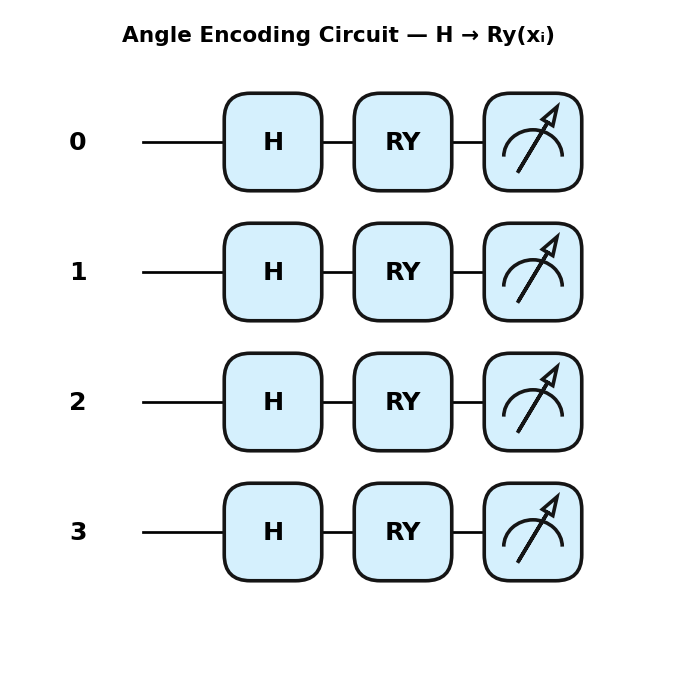


ZZ Feature Map Circuit:


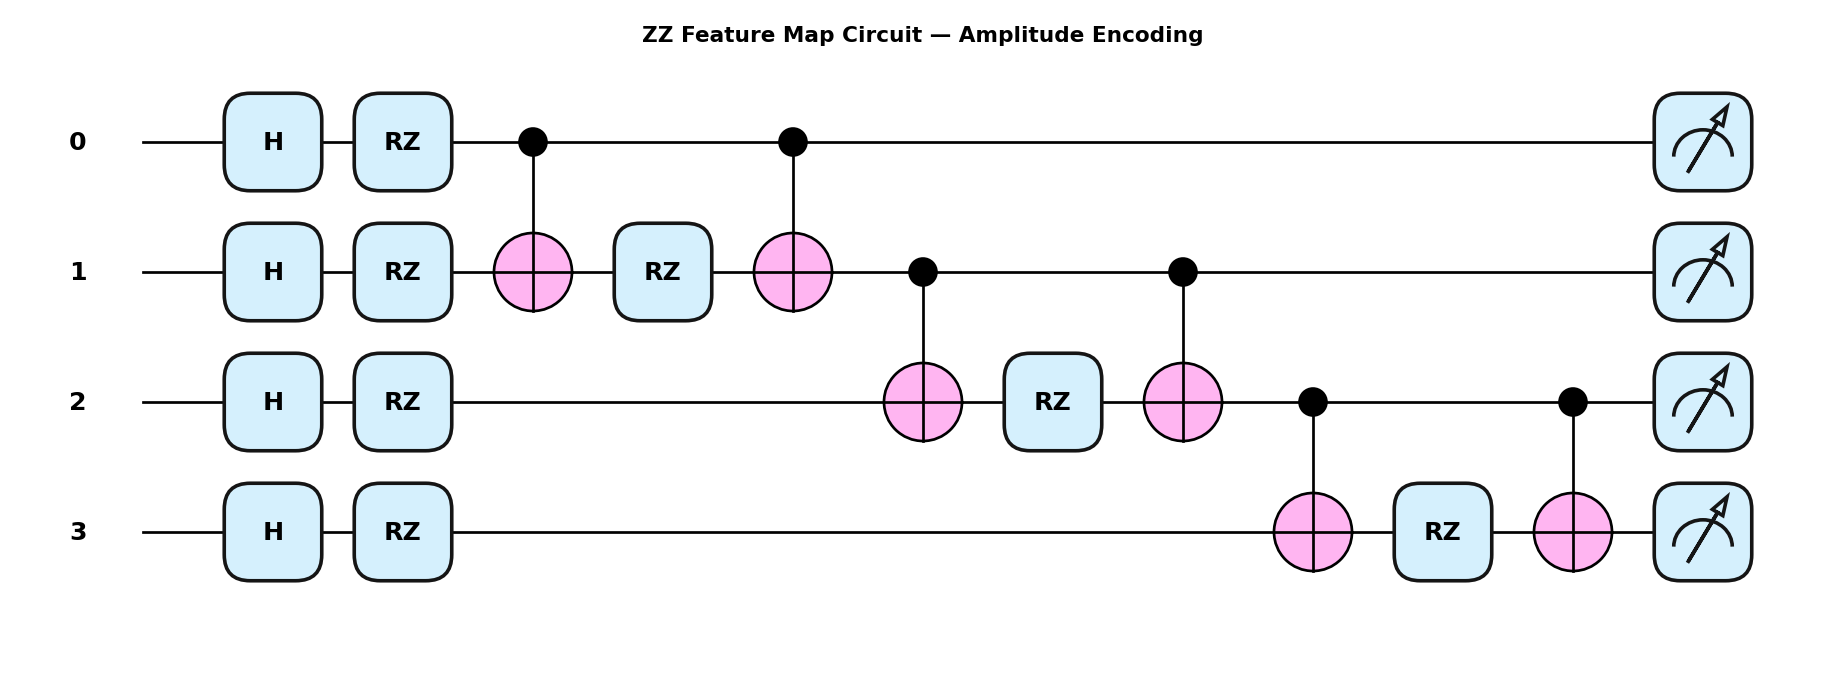

In [55]:
N_QUBITS = min(pso_mask.sum(), 4)
print(f"Quantum encoding with {N_QUBITS} qubits")

q_scaler      = MinMaxScaler(feature_range=(0, np.pi))
X_train_angle = q_scaler.fit_transform(X_train_pso)[:, :N_QUBITS]
X_test_angle  = q_scaler.transform(X_test_pso)[:, :N_QUBITS]

def angle_encode(X):
    return np.hstack([np.cos(X), np.sin(X)])

def amplitude_encode(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)
    return X / norms

X_train_qi = np.hstack([angle_encode(X_train_angle),
                         amplitude_encode(X_train_angle)])
X_test_qi  = np.hstack([angle_encode(X_test_angle),
                         amplitude_encode(X_test_angle)])

print("Quantum-inspired features — train:", X_train_qi.shape)
print("Quantum-inspired features — test :", X_test_qi.shape)

# ── Draw circuits ──────────────────────────────────────────────
from IPython.display import Image, display

dev_vis = qml.device("default.qubit", wires=N_QUBITS)
x_sample = X_train_angle[0]

@qml.qnode(dev_vis)
def angle_circuit(x):
    for i in range(N_QUBITS):
        qml.Hadamard(wires=i)
        qml.RY(x[i], wires=i)
    return qml.probs(wires=range(N_QUBITS))

@qml.qnode(dev_vis)
def zz_circuit(x):
    for i in range(N_QUBITS):
        qml.Hadamard(wires=i)
        qml.RZ(2.0 * x[i], wires=i)
    for i in range(N_QUBITS - 1):
        qml.CNOT(wires=[i, i+1])
        qml.RZ(2.0 * (np.pi - x[i]) * (np.pi - x[i+1]), wires=i+1)
        qml.CNOT(wires=[i, i+1])
    return qml.probs(wires=range(N_QUBITS))

fig1, _ = qml.draw_mpl(angle_circuit, style="pennylane")(x_sample)
fig1.suptitle("Angle Encoding Circuit — H → Ry(xᵢ)",
              fontsize=12, fontweight='bold')
fig1.savefig('circuit_angle.png', dpi=130, bbox_inches='tight')
plt.close(fig1)

fig2, _ = qml.draw_mpl(zz_circuit, style="pennylane")(x_sample)
fig2.suptitle("ZZ Feature Map Circuit — Amplitude Encoding",
              fontsize=12, fontweight='bold')
fig2.savefig('circuit_zz.png', dpi=130, bbox_inches='tight')
plt.close(fig2)

print("Angle Encoding Circuit:")
display(Image('circuit_angle.png'))
print("\nZZ Feature Map Circuit:")
display(Image('circuit_zz.png'))

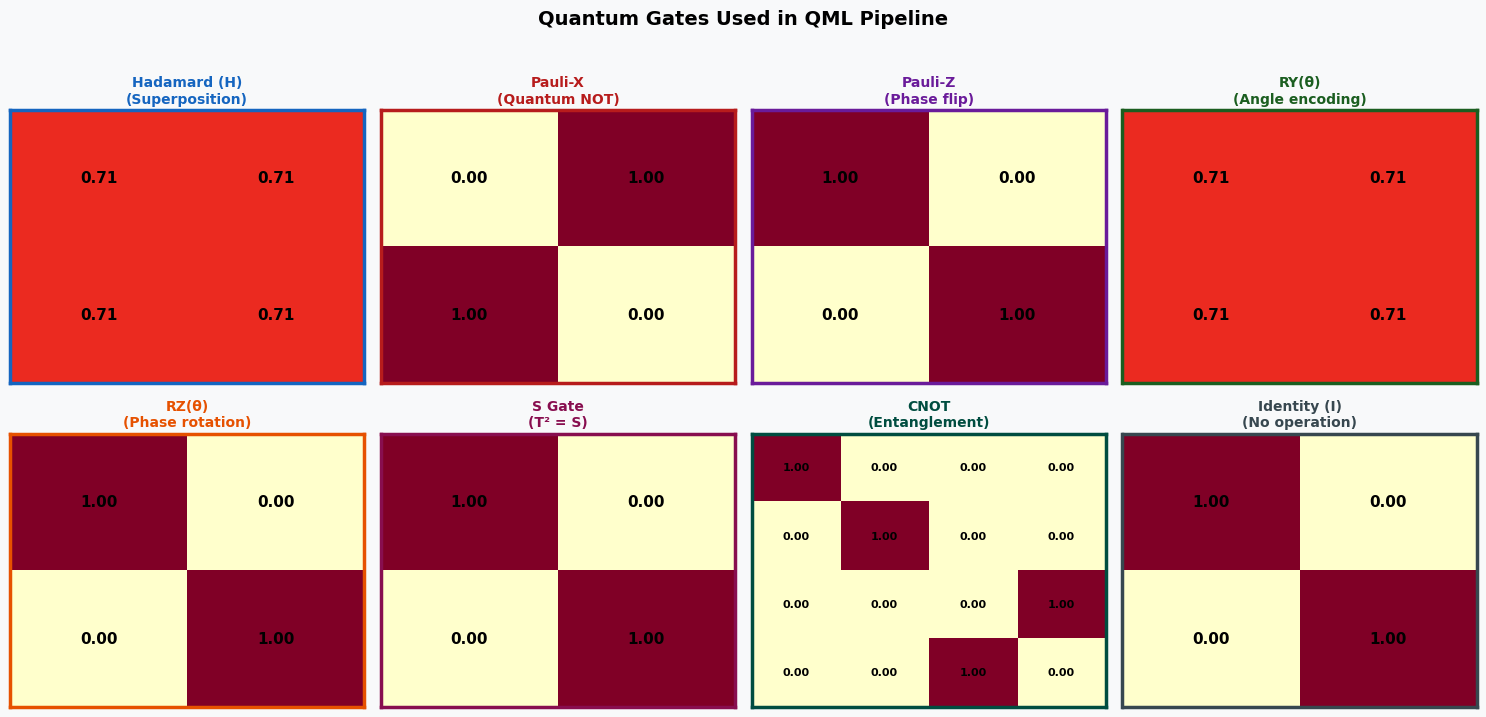

In [56]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
fig.patch.set_facecolor('#f8f9fa')

gates = [
    ("Hadamard (H)",
     np.array([[1,1],[1,-1]])/np.sqrt(2),
     '#1565C0', 'Superposition'),
    ("Pauli-X",
     np.array([[0,1],[1,0]], dtype=float),
     '#B71C1C', 'Quantum NOT'),
    ("Pauli-Z",
     np.array([[1,0],[0,-1]], dtype=float),
     '#6A1B9A', 'Phase flip'),
    ("RY(θ)",
     np.array([[np.cos(np.pi/4), -np.sin(np.pi/4)],
               [np.sin(np.pi/4),  np.cos(np.pi/4)]]),
     '#1B5E20', 'Angle encoding'),
    ("RZ(θ)",
     np.array([[1, 0],[0, np.exp(1j*np.pi/4)]]),
     '#E65100', 'Phase rotation'),
    ("S Gate",
     np.array([[1,0],[0,1j]], dtype=complex),
     '#880E4F', 'T² = S'),
    ("CNOT",
     np.array([[1,0,0,0],[0,1,0,0],
               [0,0,0,1],[0,0,1,0]], dtype=float),
     '#004D40', 'Entanglement'),
    ("Identity (I)",
     np.eye(2),
     '#37474F', 'No operation'),
]

for idx, (name, matrix, color, desc) in enumerate(gates):
    ax = axes[idx // 4][idx % 4]
    ax.set_facecolor('white')
    ax.imshow(np.abs(matrix), cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
    size = matrix.shape[0]
    for i in range(size):
        for j in range(size):
            fs = 11 if size <= 2 else 8
            ax.text(j, i, f"{abs(matrix[i,j]):.2f}",
                    ha='center', va='center',
                    color='black', fontsize=fs, fontweight='bold')
    ax.set_title(f"{name}\n({desc})", color=color,
                 fontsize=10, fontweight='bold', pad=5)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2.5)

plt.suptitle('Quantum Gates Used in QML Pipeline',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(pad=1.2)
plt.savefig('quantum_gates.png', dpi=130, bbox_inches='tight')
plt.show()

In [57]:
print("Training Quantum Kernel SVM...")
t0 = time.time()

MAX_TRAIN = 5000
if len(X_train_qi) > MAX_TRAIN:
    idx       = np.random.RandomState(42).choice(len(X_train_qi),
                                                  MAX_TRAIN, replace=False)
    X_qsvm_tr = X_train_qi[idx]
    y_qsvm_tr = y_train[idx]
else:
    X_qsvm_tr = X_train_qi
    y_qsvm_tr = y_train

qksvm = SVC(kernel='rbf', probability=True,
            random_state=42, C=1.0, gamma='scale')
qksvm.fit(X_qsvm_tr, y_qsvm_tr)

y_pred_qksvm  = qksvm.predict(X_test_qi)
y_proba_qksvm = qksvm.predict_proba(X_test_qi)[:, 1]
results['QK-SVM'] = {'pred': y_pred_qksvm, 'proba': y_proba_qksvm}

print(f"Done in {round(time.time()-t0, 2)}s")
print("\nQuantum Kernel SVM Results:")
print(classification_report(y_test, y_pred_qksvm,
      target_names=['Legitimate', 'Fraud']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_qksvm), 4))

Training Quantum Kernel SVM...
Done in 0.05s

Quantum Kernel SVM Results:
              precision    recall  f1-score   support

  Legitimate       0.87      0.91      0.89        95
       Fraud       0.90      0.86      0.88        95

    accuracy                           0.88       190
   macro avg       0.88      0.88      0.88       190
weighted avg       0.88      0.88      0.88       190

ROC-AUC: 0.9535


VQC using 4 qubits
VQC Circuit:


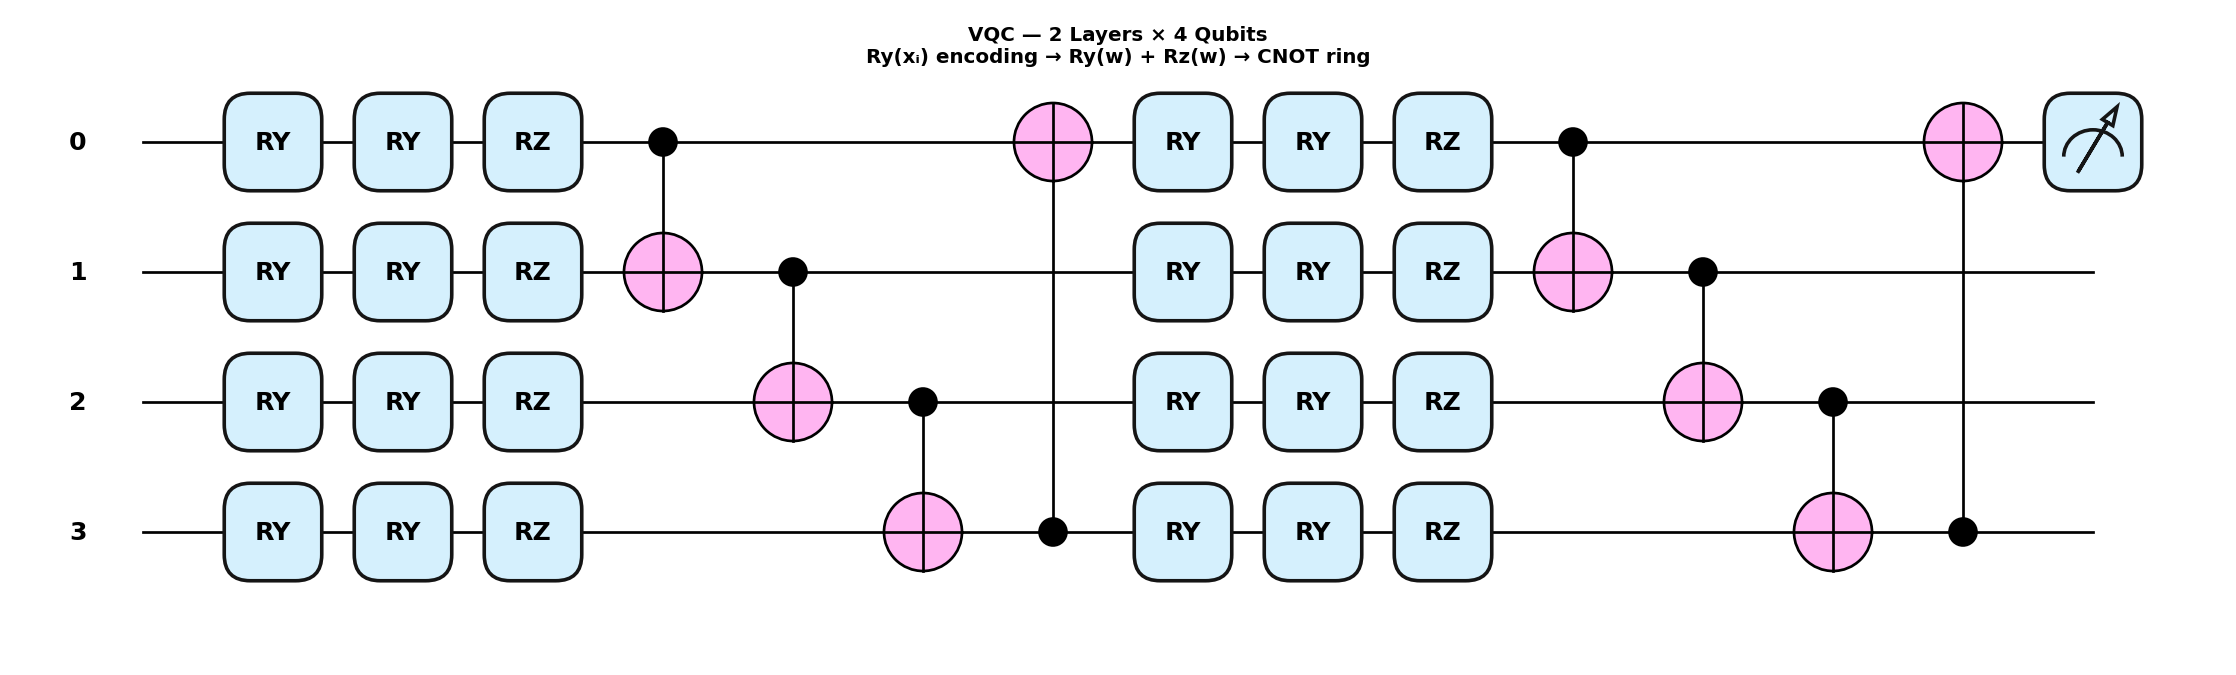

VQC train: (300, 4) | test: (100, 4)

Training VQC (20 epochs, batch=20)...
  Epoch  5/20  loss=0.5301  (34.2s elapsed)
  Epoch 10/20  loss=0.5214  (68.0s elapsed)
  Epoch 15/20  loss=0.5131  (102.3s elapsed)
  Epoch 20/20  loss=0.5322  (136.5s elapsed)

VQC trained in 136.5s

VQC Results:
              precision    recall  f1-score   support

  Legitimate       0.88      0.90      0.89        50
       Fraud       0.90      0.88      0.89        50

    accuracy                           0.89       100
   macro avg       0.89      0.89      0.89       100
weighted avg       0.89      0.89      0.89       100

ROC-AUC: 0.9728


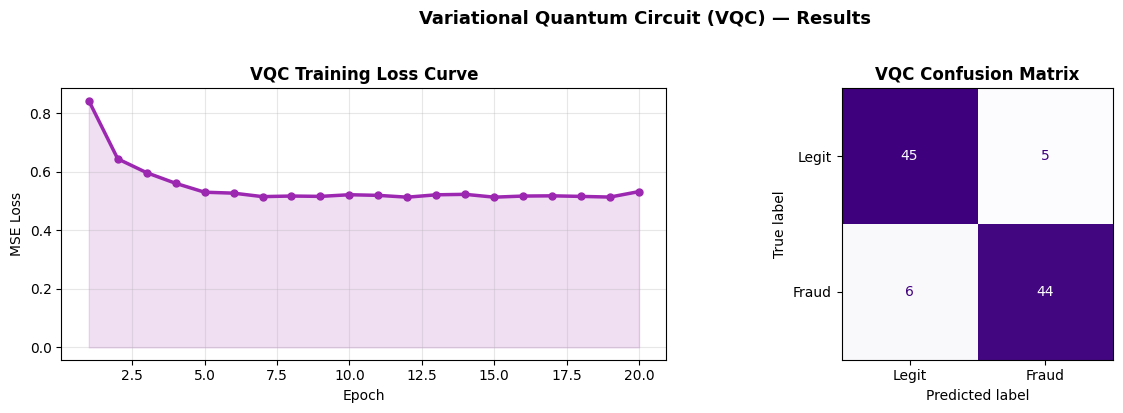

In [58]:
print(f"VQC using {N_QUBITS} qubits")

dev_vqc = qml.device("default.qubit", wires=N_QUBITS)

def vqc_layer(weights, x):
    for i in range(N_QUBITS):
        qml.RY(x[i], wires=i)
    for i in range(N_QUBITS):
        qml.RY(weights[i, 0], wires=i)
        qml.RZ(weights[i, 1], wires=i)
    for i in range(N_QUBITS - 1):
        qml.CNOT(wires=[i, i+1])
    qml.CNOT(wires=[N_QUBITS-1, 0])

N_LAYERS = 2

@qml.qnode(dev_vqc)
def vqc_circuit(weights, x):
    for l in range(N_LAYERS):
        vqc_layer(weights[l], x)
    return qml.expval(qml.PauliZ(0))

# ── Draw VQC circuit ───────────────────────────────────────────
init_w = pnp.zeros((N_LAYERS, N_QUBITS, 2))
fig_v, _ = qml.draw_mpl(vqc_circuit, style="pennylane")(init_w, X_train_angle[0])
fig_v.suptitle(
    f"VQC — {N_LAYERS} Layers × {N_QUBITS} Qubits\n"
    "Ry(xᵢ) encoding → Ry(w) + Rz(w) → CNOT ring",
    fontsize=11, fontweight='bold'
)
fig_v.savefig('circuit_vqc.png', dpi=130, bbox_inches='tight')
plt.close(fig_v)
print("VQC Circuit:")
display(Image('circuit_vqc.png'))

# ── Subsample ──────────────────────────────────────────────────
VQC_TRAIN = 300
VQC_TEST  = 100

idx_tr = np.concatenate([np.where(y_train==0)[0][:VQC_TRAIN//2],
                          np.where(y_train==1)[0][:VQC_TRAIN//2]])
idx_te = np.concatenate([np.where(y_test==0)[0][:VQC_TEST//2],
                          np.where(y_test==1)[0][:VQC_TEST//2]])

X_vqc_tr  = X_train_angle[idx_tr]
y_vqc_tr  = y_train[idx_tr]
X_vqc_te  = X_test_angle[idx_te]
y_vqc_te  = y_test[idx_te]
y_vqc_pm  = np.where(y_vqc_tr == 1, 1.0, -1.0)

print(f"VQC train: {X_vqc_tr.shape} | test: {X_vqc_te.shape}")

# ── Training loop ──────────────────────────────────────────────
np.random.seed(42)
weights = pnp.array(
    np.random.uniform(-np.pi, np.pi, (N_LAYERS, N_QUBITS, 2)),
    requires_grad=True
)

opt          = qml.AdamOptimizer(stepsize=0.05)
EPOCHS       = 20
BATCH_SIZE   = 20
loss_history = []

print(f"\nTraining VQC ({EPOCHS} epochs, batch={BATCH_SIZE})...")
t0 = time.time()

for epoch in range(EPOCHS):
    perm   = np.random.permutation(len(X_vqc_tr))
    X_shuf = X_vqc_tr[perm]
    y_shuf = y_vqc_pm[perm]
    epoch_loss = 0.0
    n_batches  = 0

    for start in range(0, len(X_shuf), BATCH_SIZE):
        Xb = X_shuf[start:start+BATCH_SIZE]
        yb = y_shuf[start:start+BATCH_SIZE]

        def cost_fn(w):
            preds = pnp.array([vqc_circuit(w, x) for x in Xb])
            return pnp.mean((preds - yb) ** 2)

        weights, loss_val = opt.step_and_cost(cost_fn, weights)
        epoch_loss += float(loss_val)
        n_batches  += 1

    avg_loss = epoch_loss / n_batches
    loss_history.append(avg_loss)
    if (epoch+1) % 5 == 0:
        print(f"  Epoch {epoch+1:>2}/{EPOCHS}  loss={avg_loss:.4f}  "
              f"({round(time.time()-t0,1)}s elapsed)")

print(f"\nVQC trained in {round(time.time()-t0, 1)}s")

# ── Inference ──────────────────────────────────────────────────
raw_scores    = np.array([float(vqc_circuit(weights, x)) for x in X_vqc_te])
y_proba_vqc   = (raw_scores + 1) / 2
y_pred_vqc    = (y_proba_vqc >= 0.5).astype(int)
results['VQC'] = {'pred': y_pred_vqc, 'proba': y_proba_vqc,
                   'y_test': y_vqc_te}

print("\nVQC Results:")
print(classification_report(y_vqc_te, y_pred_vqc,
      target_names=['Legitimate', 'Fraud']))
print("ROC-AUC:", round(roc_auc_score(y_vqc_te, y_proba_vqc), 4))

# ── VQC plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, EPOCHS+1), loss_history,
             color='#9C27B0', linewidth=2.5, marker='o', markersize=5)
axes[0].fill_between(range(1, EPOCHS+1), loss_history,
                     alpha=0.15, color='#9C27B0')
axes[0].set_title('VQC Training Loss Curve', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].grid(True, alpha=0.3)

disp = ConfusionMatrixDisplay(
    confusion_matrix(y_vqc_te, y_pred_vqc),
    display_labels=['Legit', 'Fraud']
)
disp.plot(ax=axes[1], colorbar=False, cmap='Purples')
axes[1].set_title('VQC Confusion Matrix', fontweight='bold', fontsize=12)

plt.suptitle('Variational Quantum Circuit (VQC) — Results',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [59]:
# VQC uses its own subset — use only common models for fusion
W_RF    = 0.25
W_XGB   = 0.30
W_OCSVM = 0.15
W_QKSVM = 0.30

y_hybrid_score = (
    W_RF    * results['Random Forest']['proba'] +
    W_XGB   * results['XGBoost']['proba']       +
    W_OCSVM * results['OC-SVM']['proba']        +
    W_QKSVM * results['QK-SVM']['proba']
)

# Best threshold by F1
precisions, recalls, thresholds = precision_recall_curve(y_test, y_hybrid_score)
f1s        = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_thresh = thresholds[np.argmax(f1s)]
y_hybrid_pred = (y_hybrid_score >= best_thresh).astype(int)

print(f"Best threshold : {best_thresh:.4f}")
print(f"Best F1        : {f1s.max():.4f}")
print("\nHybrid Fusion Results:")
print(classification_report(y_test, y_hybrid_pred,
      target_names=['Legitimate', 'Fraud']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_hybrid_score), 4))

results['Hybrid'] = {'pred': y_hybrid_pred, 'proba': y_hybrid_score}

Best threshold : 0.4435
Best F1        : 0.9297

Hybrid Fusion Results:
              precision    recall  f1-score   support

  Legitimate       0.91      0.96      0.93        95
       Fraud       0.96      0.91      0.93        95

    accuracy                           0.93       190
   macro avg       0.93      0.93      0.93       190
weighted avg       0.93      0.93      0.93       190

ROC-AUC: 0.9609


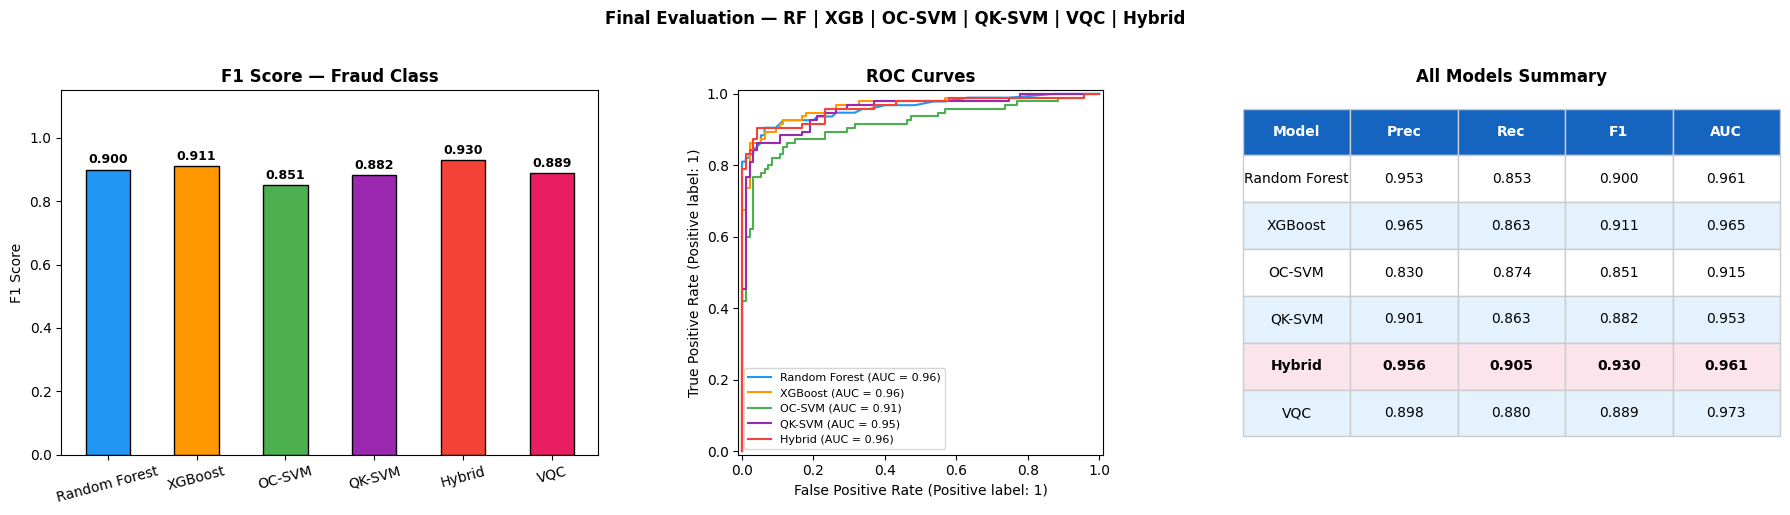


✓ All models trained and evaluated!
RF | XGBoost | OC-SVM | QK-SVM | VQC | Hybrid Fusion


In [60]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bar_cols = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336', '#E91E63']

# Models with shared test set
shared_models = ['Random Forest', 'XGBoost', 'OC-SVM', 'QK-SVM', 'Hybrid']
vqc_model     = 'VQC'

# ── F1 comparison (all 6 models) ───────────────────────────────
all_models = shared_models + [vqc_model]
f1_vals = []
for m in all_models:
    yt = results[m].get('y_test', y_test)
    f1_vals.append(f1_score(yt, results[m]['pred'],
                             pos_label=1, zero_division=0))

bars = axes[0].bar(all_models, f1_vals, color=bar_cols,
                   edgecolor='black', width=0.5)
axes[0].set_ylim(0, 1.15)
axes[0].set_title('F1 Score — Fraud Class', fontweight='bold', fontsize=12)
axes[0].set_ylabel('F1 Score')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, f1_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 0.02, f'{val:.3f}',
                 ha='center', fontweight='bold', fontsize=9)

# ── ROC curves (shared test set only) ─────────────────────────
for i, m in enumerate(shared_models):
    RocCurveDisplay.from_predictions(
        y_test, results[m]['proba'], name=m, ax=axes[1],
        color=bar_cols[i]
    )
axes[1].set_title('ROC Curves', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=8)

# ── Summary table (all models) ────────────────────────────────
axes[2].axis('off')
header = ['Model', 'Prec', 'Rec', 'F1', 'AUC']
rows   = []
for m in all_models:
    yt  = results[m].get('y_test', y_test)
    p   = precision_score(yt, results[m]['pred'], pos_label=1, zero_division=0)
    r   = recall_score(yt,    results[m]['pred'], pos_label=1, zero_division=0)
    f1  = f1_score(yt,        results[m]['pred'], pos_label=1, zero_division=0)
    auc = roc_auc_score(yt,   results[m]['proba'])
    rows.append([m, f'{p:.3f}', f'{r:.3f}', f'{f1:.3f}', f'{auc:.3f}'])

table = axes[2].table(cellText=rows, colLabels=header,
                       cellLoc='center', loc='center',
                       bbox=[0, 0.05, 1, 0.9])
table.auto_set_font_size(False)
table.set_fontsize(10)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    elif rows[r-1][0] == 'Hybrid':
        cell.set_facecolor('#FCE4EC')
        cell.set_text_props(fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#E3F2FD')
    cell.set_edgecolor('#cccccc')
axes[2].set_title('All Models Summary', fontweight='bold', fontsize=12)

plt.suptitle('Final Evaluation — RF | XGB | OC-SVM | QK-SVM | VQC | Hybrid',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ All models trained and evaluated!")
print("RF | XGBoost | OC-SVM | QK-SVM | VQC | Hybrid Fusion")

Tuning Random Forest...
Best RF params: {'n_estimators': 100, 'min_samples_split': 5, 'max_features': 'log2', 'max_depth': 10}

Tuned RF:
              precision    recall  f1-score   support

  Legitimate       0.87      0.97      0.92        95
       Fraud       0.96      0.85      0.91        95

    accuracy                           0.91       190
   macro avg       0.92      0.91      0.91       190
weighted avg       0.92      0.91      0.91       190

Tuning XGBoost...
Best XGB params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

Tuned XGB:
              precision    recall  f1-score   support

  Legitimate       0.88      0.97      0.92        95
       Fraud       0.96      0.86      0.91        95

    accuracy                           0.92       190
   macro avg       0.92      0.92      0.92       190
weighted avg       0.92      0.92      0.92       190



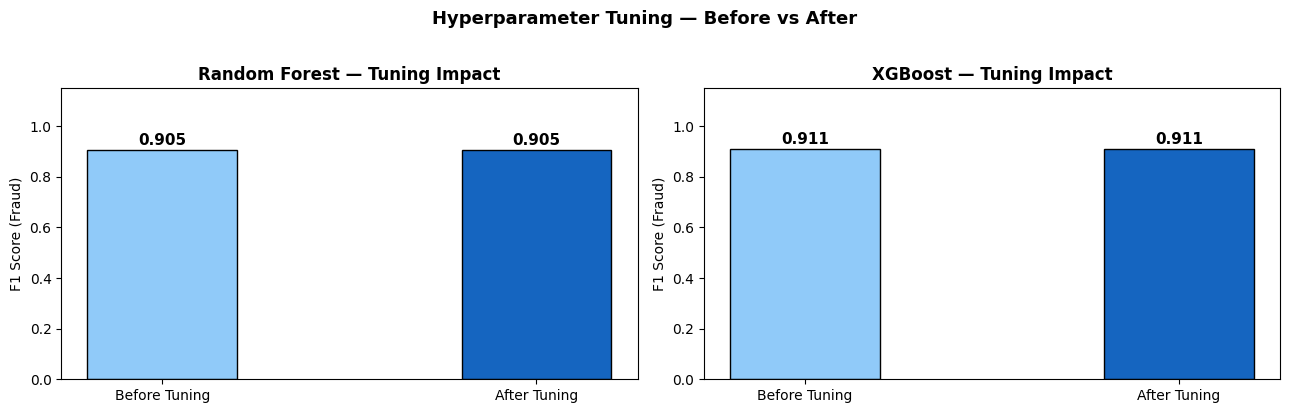

In [61]:
from sklearn.model_selection import RandomizedSearchCV

print("Tuning Random Forest...")
rf_params = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features':      ['sqrt', 'log2']
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params, n_iter=10, cv=3, scoring='f1',
    random_state=42, n_jobs=-1, verbose=0
)
rf_search.fit(X_train_pso, y_train)
best_rf = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)

y_pred_rf_tuned  = best_rf.predict(X_test_pso)
y_proba_rf_tuned = best_rf.predict_proba(X_test_pso)[:, 1]
print("\nTuned RF:")
print(classification_report(y_test, y_pred_rf_tuned,
      target_names=['Legitimate', 'Fraud']))

print("Tuning XGBoost...")
xgb_params = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 6, 9],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    xgb_params, n_iter=10, cv=3, scoring='f1',
    random_state=42, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train_pso, y_train)
best_xgb = xgb_search.best_estimator_
print("Best XGB params:", xgb_search.best_params_)

y_pred_xgb_tuned  = best_xgb.predict(X_test_pso)
y_proba_xgb_tuned = best_xgb.predict_proba(X_test_pso)[:, 1]
print("\nTuned XGB:")
print(classification_report(y_test, y_pred_xgb_tuned,
      target_names=['Legitimate', 'Fraud']))

# Update results
results['Random Forest'] = {'pred': y_pred_rf_tuned,  'proba': y_proba_rf_tuned}
results['XGBoost']       = {'pred': y_pred_xgb_tuned, 'proba': y_proba_xgb_tuned}

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, (name, before_pred, tuned_pred) in enumerate([
    ('Random Forest', results['Random Forest']['pred'], y_pred_rf_tuned),
    ('XGBoost',       results['XGBoost']['pred'],       y_pred_xgb_tuned),
]):
    f1_before = f1_score(y_test, before_pred, pos_label=1, zero_division=0)
    f1_after  = f1_score(y_test, tuned_pred,  pos_label=1, zero_division=0)
    bars = axes[i].bar(['Before Tuning', 'After Tuning'],
                        [f1_before, f1_after],
                        color=['#90CAF9', '#1565C0'],
                        edgecolor='black', width=0.4)
    axes[i].set_ylim(0, 1.15)
    axes[i].set_title(f'{name} — Tuning Impact', fontweight='bold')
    axes[i].set_ylabel('F1 Score (Fraud)')
    for bar, val in zip(bars, [f1_before, f1_after]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     val + 0.02, f'{val:.3f}',
                     ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Hyperparameter Tuning — Before vs After',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

5-Fold Cross Validation...

  Random Forest        F1: 0.9384 ± 0.0115
  XGBoost              F1: 0.9372 ± 0.0147
  QK-SVM               F1: 0.8685 ± 0.0276


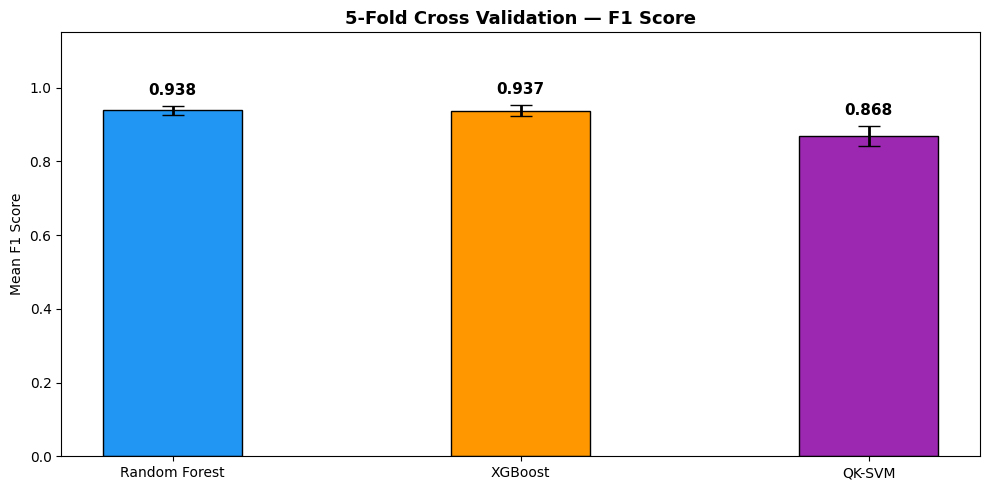

In [62]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Random Forest': (best_rf,  X_train_pso, y_train),
    'XGBoost':       (best_xgb, X_train_pso, y_train),
    'QK-SVM':        (qksvm,    X_train_qi,  y_train),
}

cv_results = {}
print("5-Fold Cross Validation...\n")
for name, (model, Xc, yc) in cv_models.items():
    scores = cross_val_score(model, Xc, yc,
                              cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:<20} F1: {scores.mean():.4f} ± {scores.std():.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
names  = list(cv_results.keys())
means  = [cv_results[n].mean() for n in names]
stds   = [cv_results[n].std()  for n in names]
colors = ['#2196F3', '#FF9800', '#9C27B0']

bars = ax.bar(names, means, yerr=stds, capsize=8,
              color=colors, edgecolor='black', width=0.4,
              error_kw={'linewidth': 2})
ax.set_ylim(0, 1.15)
ax.set_title('5-Fold Cross Validation — F1 Score',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Mean F1 Score')
for bar, val, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + std + 0.03, f'{val:.3f}',
            ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

Computing SHAP values...


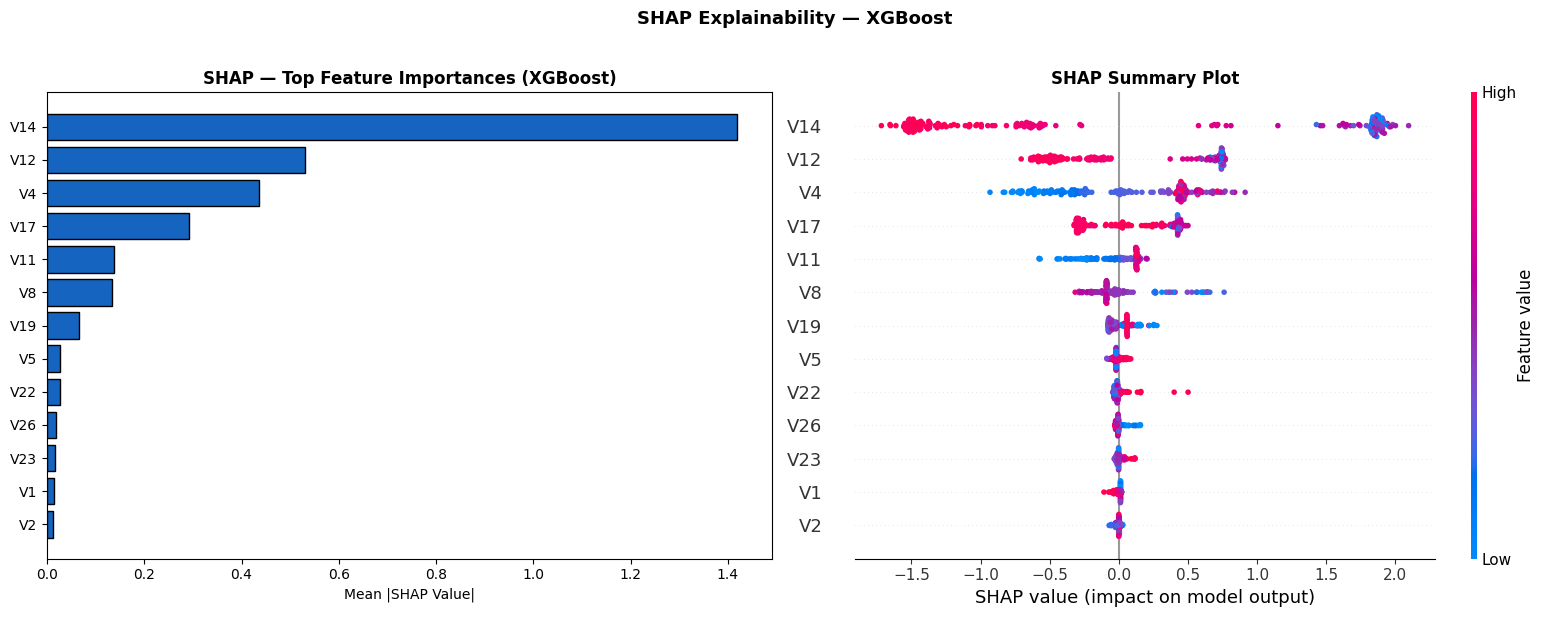

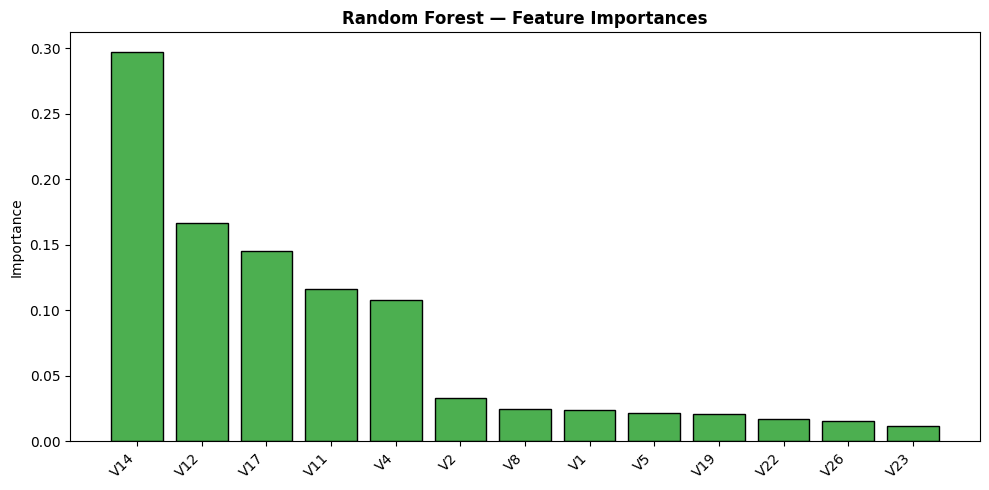

In [63]:
!pip install shap --quiet
import shap

print("Computing SHAP values...")
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_pso)

selected_feat_names = [feature_names[i]
                        for i in range(len(feature_names)) if pso_mask[i]]
top_n = min(15, len(selected_feat_names))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mean_shap  = np.abs(shap_values).mean(axis=0)
sorted_idx = np.argsort(mean_shap)[::-1]

axes[0].barh(
    [selected_feat_names[i] for i in sorted_idx[:top_n]][::-1],
    mean_shap[sorted_idx[:top_n]][::-1],
    color='#1565C0', edgecolor='black'
)
axes[0].set_title('SHAP — Top Feature Importances (XGBoost)',
                   fontweight='bold', fontsize=12)
axes[0].set_xlabel('Mean |SHAP Value|')

plt.sca(axes[1])
shap.summary_plot(shap_values, X_test_pso,
                  feature_names=selected_feat_names,
                  show=False, plot_size=None)
axes[1].set_title('SHAP Summary Plot', fontweight='bold', fontsize=12)

plt.suptitle('SHAP Explainability — XGBoost',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# RF importance
fig, ax = plt.subplots(figsize=(10, 5))
rf_imp     = best_rf.feature_importances_
sorted_rf  = np.argsort(rf_imp)[::-1][:top_n]
ax.bar(range(top_n), rf_imp[sorted_rf],
       color='#4CAF50', edgecolor='black')
ax.set_xticks(range(top_n))
ax.set_xticklabels([selected_feat_names[i] for i in sorted_rf],
                    rotation=45, ha='right')
ax.set_title('Random Forest — Feature Importances',
             fontweight='bold', fontsize=12)
ax.set_ylabel('Importance')
plt.tight_layout()
plt.show()

In [64]:
from sklearn.metrics import (
    matthews_corrcoef, balanced_accuracy_score,
    average_precision_score, PrecisionRecallDisplay
)

print("=" * 60)
print("COMPLETE FINAL EVALUATION")
print("=" * 60)

eval_models = {
    'Random Forest': (y_test, results['Random Forest']['pred'], results['Random Forest']['proba']),
    'XGBoost':       (y_test, results['XGBoost']['pred'],       results['XGBoost']['proba']),
    'OC-SVM':        (y_test, results['OC-SVM']['pred'],        results['OC-SVM']['proba']),
    'QK-SVM':        (y_test, results['QK-SVM']['pred'],        results['QK-SVM']['proba']),
    'VQC':           (results['VQC']['y_test'], results['VQC']['pred'], results['VQC']['proba']),
    'Hybrid':        (y_test, results['Hybrid']['pred'],        results['Hybrid']['proba']),
}

metrics_rows = []
for name, (yt, yp, yprob) in eval_models.items():
    row = {
        'Model':     name,
        'Bal.Acc':   round(balanced_accuracy_score(yt, yp), 4),
        'Precision': round(precision_score(yt, yp, pos_label=1, zero_division=0), 4),
        'Recall':    round(recall_score(yt, yp,    pos_label=1, zero_division=0), 4),
        'F1':        round(f1_score(yt, yp,        pos_label=1, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(yt, yprob), 4),
        'PR-AUC':    round(average_precision_score(yt, yprob), 4),
        'MCC':       round(matthews_corrcoef(yt, yp), 4),
    }
    metrics_rows.append(row)
    print(f"\n{name}")
    for k, v in row.items():
        if k != 'Model':
            print(f"  {k:<12}: {v}")

metrics_df = pd.DataFrame(metrics_rows).set_index('Model')
print("\nFULL TABLE:")
print(metrics_df.to_string())

COMPLETE FINAL EVALUATION

Random Forest
  Bal.Acc     : 0.9105
  Precision   : 0.9643
  Recall      : 0.8526
  F1          : 0.905
  ROC-AUC     : 0.9627
  PR-AUC      : 0.9715
  MCC         : 0.8266

XGBoost
  Bal.Acc     : 0.9158
  Precision   : 0.9647
  Recall      : 0.8632
  F1          : 0.9111
  ROC-AUC     : 0.9579
  PR-AUC      : 0.9689
  MCC         : 0.8362

OC-SVM
  Bal.Acc     : 0.8474
  Precision   : 0.83
  Recall      : 0.8737
  F1          : 0.8513
  ROC-AUC     : 0.9147
  PR-AUC      : 0.9347
  MCC         : 0.6957

QK-SVM
  Bal.Acc     : 0.8842
  Precision   : 0.9011
  Recall      : 0.8632
  F1          : 0.8817
  ROC-AUC     : 0.9535
  PR-AUC      : 0.9613
  MCC         : 0.7691

VQC
  Bal.Acc     : 0.89
  Precision   : 0.898
  Recall      : 0.88
  F1          : 0.8889
  ROC-AUC     : 0.9728
  PR-AUC      : 0.9764
  MCC         : 0.7802

Hybrid
  Bal.Acc     : 0.9316
  Precision   : 0.9556
  Recall      : 0.9053
  F1          : 0.9297
  ROC-AUC     : 0.9609
  PR-AUC 

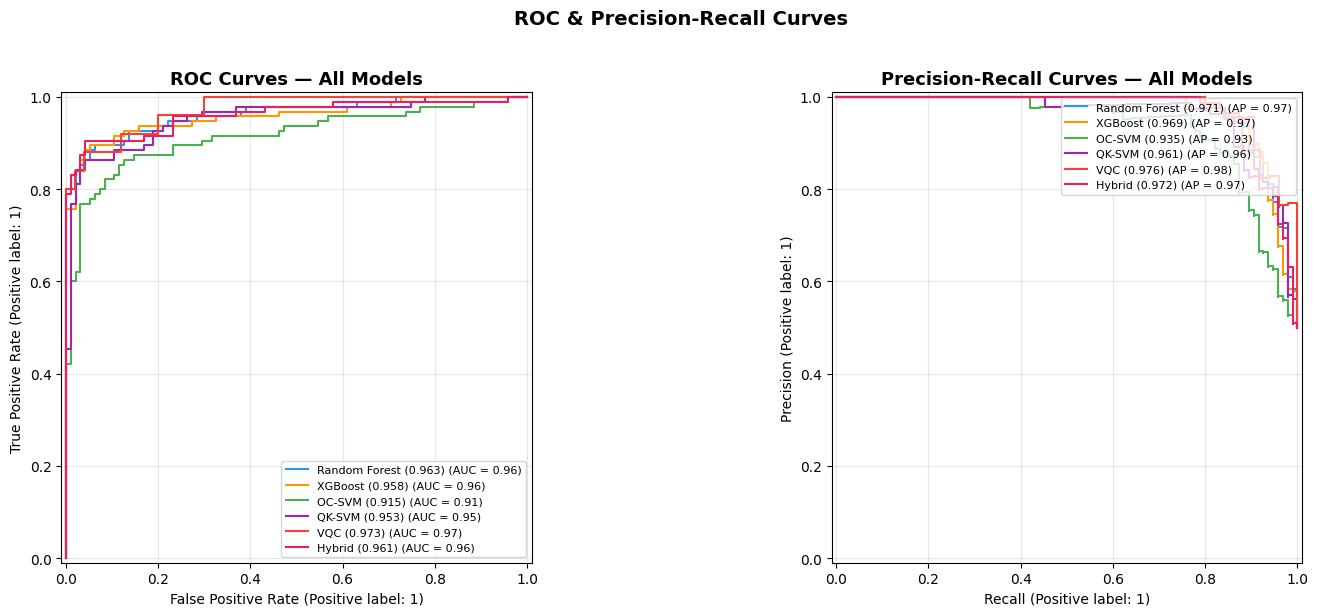

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#2196F3','#FF9800','#4CAF50','#9C27B0','#F44336','#E91E63']

for (name, (yt, yp, yprob)), col in zip(eval_models.items(), colors):
    RocCurveDisplay.from_predictions(
        yt, yprob,
        name=f"{name} ({roc_auc_score(yt, yprob):.3f})",
        ax=axes[0], color=col
    )
axes[0].set_title('ROC Curves — All Models', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=8, loc='lower right')
axes[0].grid(True, alpha=0.3)

for (name, (yt, yp, yprob)), col in zip(eval_models.items(), colors):
    PrecisionRecallDisplay.from_predictions(
        yt, yprob,
        name=f"{name} ({average_precision_score(yt, yprob):.3f})",
        ax=axes[1], color=col
    )
axes[1].set_title('Precision-Recall Curves — All Models',
                   fontweight='bold', fontsize=13)
axes[1].legend(fontsize=8, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('ROC & Precision-Recall Curves',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

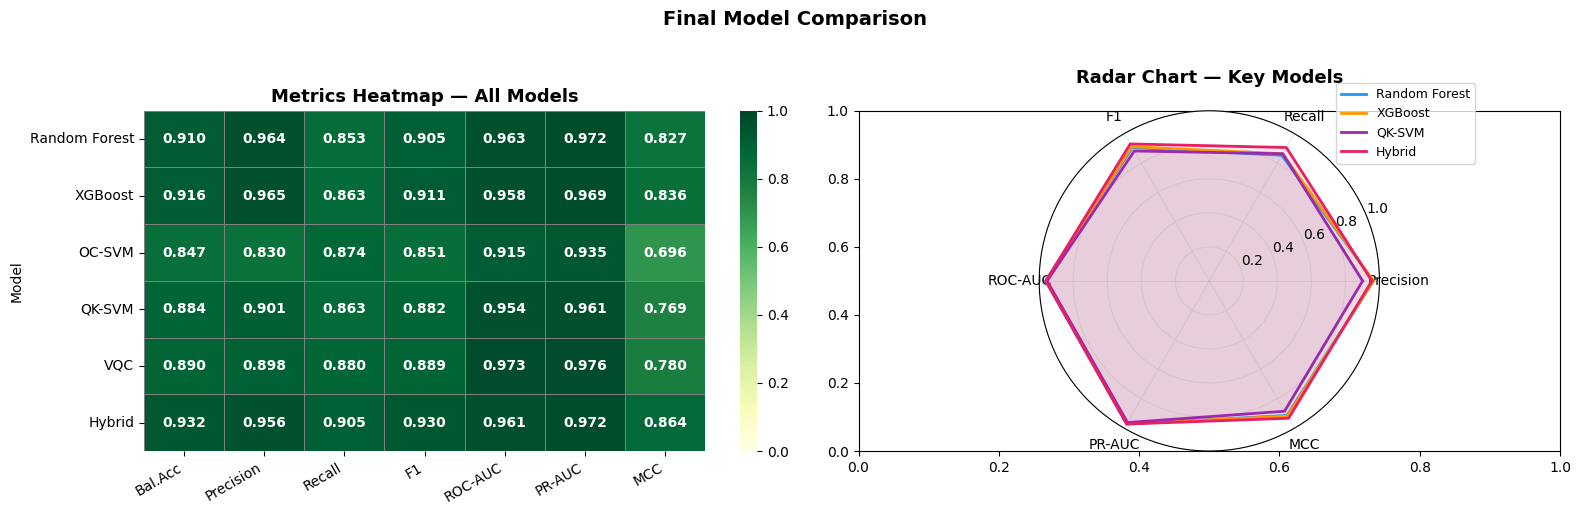

In [66]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    metrics_df.astype(float),
    annot=True, fmt='.3f', cmap='YlGn',
    linewidths=0.5, linecolor='gray',
    ax=axes[0], vmin=0, vmax=1,
    annot_kws={'fontsize': 10, 'fontweight': 'bold'}
)
axes[0].set_title('Metrics Heatmap — All Models',
                   fontweight='bold', fontsize=13)
axes[0].set_xticklabels(axes[0].get_xticklabels(),
                         rotation=30, ha='right')

# Radar
radar_metrics = ['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC', 'MCC']
radar_models  = ['Random Forest', 'XGBoost', 'QK-SVM', 'Hybrid']
radar_colors  = ['#2196F3', '#FF9800', '#9C27B0', '#E91E63']
N      = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

ax_r = fig.add_subplot(122, polar=True)
for model, color in zip(radar_models, radar_colors):
    vals = metrics_df.loc[model, radar_metrics].tolist()
    vals[-1] = (vals[-1] + 1) / 2   # normalize MCC to [0,1]
    vals += vals[:1]
    ax_r.plot(angles, vals, color=color, linewidth=2, label=model)
    ax_r.fill(angles, vals, color=color, alpha=0.08)

ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(radar_metrics, fontsize=10)
ax_r.set_ylim(0, 1)
ax_r.set_title('Radar Chart — Key Models',
                fontweight='bold', fontsize=13, pad=20)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
ax_r.grid(True, alpha=0.3)

plt.suptitle('Final Model Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [67]:
import pickle, zipfile, os
import pennylane as qml
from pennylane import numpy as pnp

SAVE_DIR = '/kaggle/working/models'
os.makedirs(SAVE_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════
# Define VQC circuit at MODULE LEVEL (fixes pickle error)
# ══════════════════════════════════════════════════════════════

_N_QUBITS = int(N_QUBITS)
_N_LAYERS = int(N_LAYERS)
_dev      = qml.device("default.qubit", wires=_N_QUBITS)

@qml.qnode(_dev)
def _vqc_circuit_global(weights, x):
    for l in range(_N_LAYERS):
        for i in range(_N_QUBITS):
            qml.RY(x[i], wires=i)
        for i in range(_N_QUBITS):
            qml.RY(weights[l, i, 0], wires=i)
            qml.RZ(weights[l, i, 1], wires=i)
        for i in range(_N_QUBITS - 1):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[_N_QUBITS-1, 0])
    return qml.expval(qml.PauliZ(0))

print("Global VQC circuit defined ✓")

# ══════════════════════════════════════════════════════════════
# HybridFraudDetector class (pickle-safe)
# ══════════════════════════════════════════════════════════════

class HybridFraudDetector:
    """
    Full architecture-faithful inference pipeline.
    Flow:
      Raw Input
        → MinMaxScaler (Time + Amount)
        → PSO mask (feature selection)
        → RF score
        → XGB score
        → OC-SVM score
        → Quantum angle scaler → Angle + Amplitude encoding
        → QK-SVM score
        → VQC score
        → Weighted hybrid fusion
        → Threshold → Decision
    """

    def __init__(self,
                 minmax_scaler, pso_mask, feature_names,
                 rf, xgb, ocsvm,
                 q_scaler, n_qubits, n_layers, vqc_weights, qksvm,
                 hybrid_config):

        self.minmax_scaler   = minmax_scaler
        self.pso_mask        = pso_mask
        self.feature_names   = feature_names

        self.rf              = rf
        self.xgb             = xgb
        self.ocsvm           = ocsvm

        self.q_scaler        = q_scaler
        self.n_qubits        = n_qubits
        self.n_layers        = n_layers
        self.vqc_weights     = vqc_weights
        self.qksvm           = qksvm

        self.w_rf            = hybrid_config['w_rf']
        self.w_xgb           = hybrid_config['w_xgb']
        self.w_ocsvm         = hybrid_config['w_ocsvm']
        self.w_qksvm         = hybrid_config['w_qksvm']
        self.threshold       = hybrid_config['threshold']

    # ── Helpers ────────────────────────────────────────────────
    def _angle_encode(self, X):
        return np.hstack([np.cos(X), np.sin(X)])

    def _amplitude_encode(self, X):
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms = np.where(norms == 0, 1, norms)
        return X / norms

    def _normalize_score(self, scores):
        mn, mx = scores.min(), scores.max()
        if mx - mn < 1e-9:
            return np.zeros_like(scores)
        return (scores - mn) / (mx - mn)

    def _run_vqc(self, X_angle):
        """Run VQC using global circuit (pickle-safe)"""
        raw = np.array([
            float(_vqc_circuit_global(self.vqc_weights, x))
            for x in X_angle
        ])
        return (raw + 1) / 2   # [-1,1] → [0,1]

    # ── Predict ────────────────────────────────────────────────
    def predict(self, X_raw):
        """
        X_raw : np.array (n_samples, 30) — raw unscaled features
        Returns: predictions (0/1), fraud_scores (float)
        """
        X = X_raw.copy().astype(float)

        # Stage 1: Normalize Time + Amount
        time_idx   = self.feature_names.index('Time')
        amount_idx = self.feature_names.index('Amount')
        X[:, [time_idx, amount_idx]] = self.minmax_scaler.transform(
            X[:, [time_idx, amount_idx]]
        )

        # Stage 2: PSO feature selection
        X_pso = X[:, self.pso_mask]

        # Stage 3: Classical scores
        score_rf    = self.rf.predict_proba(X_pso)[:, 1]
        score_xgb   = self.xgb.predict_proba(X_pso)[:, 1]
        score_ocsvm = self._normalize_score(
                          -self.ocsvm.decision_function(X_pso))

        # Stage 4: Quantum encoding
        X_angle = self.q_scaler.transform(X_pso)[:, :self.n_qubits]
        X_qi    = np.hstack([self._angle_encode(X_angle),
                              self._amplitude_encode(X_angle)])

        # Stage 5: QK-SVM score
        score_qksvm = self.qksvm.predict_proba(X_qi)[:, 1]

        # Stage 6: VQC score
        score_vqc = self._run_vqc(X_angle)

        # Stage 7: Hybrid fusion
        quantum_score = (score_qksvm + score_vqc) / 2
        hybrid_score  = (
            self.w_rf    * score_rf      +
            self.w_xgb   * score_xgb     +
            self.w_ocsvm * score_ocsvm   +
            self.w_qksvm * quantum_score
        )

        # Stage 8: Threshold → decision
        predictions = (hybrid_score >= self.threshold).astype(int)
        return predictions, hybrid_score

    def predict_single(self, x_raw):
        """Single transaction prediction (1D array length 30)"""
        X = x_raw.reshape(1, -1).copy().astype(float)

        # Normalize
        time_idx   = self.feature_names.index('Time')
        amount_idx = self.feature_names.index('Amount')
        X[:, [time_idx, amount_idx]] = self.minmax_scaler.transform(
            X[:, [time_idx, amount_idx]]
        )
        X_pso = X[:, self.pso_mask]

        # Individual scores for dashboard display
        s_rf    = float(self.rf.predict_proba(X_pso)[0, 1])
        s_xgb   = float(self.xgb.predict_proba(X_pso)[0, 1])
        s_ocsvm = float(self._normalize_score(
                            -self.ocsvm.decision_function(X_pso))[0])

        X_angle  = self.q_scaler.transform(X_pso)[:, :self.n_qubits]
        X_qi     = np.hstack([self._angle_encode(X_angle),
                               self._amplitude_encode(X_angle)])
        s_qksvm  = float(self.qksvm.predict_proba(X_qi)[0, 1])
        s_vqc    = float(self._run_vqc(X_angle)[0])
        s_quantum = (s_qksvm + s_vqc) / 2

        fraud_score = (self.w_rf    * s_rf      +
                       self.w_xgb   * s_xgb     +
                       self.w_ocsvm * s_ocsvm   +
                       self.w_qksvm * s_quantum)

        pred  = int(fraud_score >= self.threshold)
        label = "FRAUD" if pred == 1 else "LEGITIMATE"

        return {
            'prediction':     pred,
            'label':          label,
            'fraud_score':    round(fraud_score, 4),
            'threshold':      round(self.threshold, 4),
            'rf_score':       round(s_rf, 4),
            'xgb_score':      round(s_xgb, 4),
            'ocsvm_score':    round(s_ocsvm, 4),
            'qksvm_score':    round(s_qksvm, 4),
            'vqc_score':      round(s_vqc, 4),
            'quantum_score':  round(s_quantum, 4),
        }

print("HybridFraudDetector class defined ✓")

# ══════════════════════════════════════════════════════════════
# Instantiate
# ══════════════════════════════════════════════════════════════

detector = HybridFraudDetector(
    minmax_scaler  = scaler,
    pso_mask       = pso_mask,
    feature_names  = feature_names,
    rf             = best_rf,
    xgb            = best_xgb,
    ocsvm          = ocsvm,
    q_scaler       = q_scaler,
    n_qubits       = N_QUBITS,
    n_layers       = N_LAYERS,
    vqc_weights    = weights,
    qksvm          = qksvm,
    hybrid_config  = {
        'w_rf':      0.25,
        'w_xgb':     0.30,
        'w_ocsvm':   0.15,
        'w_qksvm':   0.30,
        'threshold': best_thresh,
    }
)
print("Pipeline instantiated ✓")

# ══════════════════════════════════════════════════════════════
# Verify
# ══════════════════════════════════════════════════════════════

print("\nVerifying on 5 samples:")
print(f"{'#':<4} {'True':<12} {'Pred':<12} {'Score':<8} "
      f"{'RF':<7} {'XGB':<7} {'QKSVM':<7} {'VQC':<7}")
print("-" * 62)
for i in range(5):
    r = detector.predict_single(X_test[i])
    t = "FRAUD" if y_test[i] == 1 else "LEGIT"
    print(f"  {i:<3} {t:<12} {r['label']:<12} "
          f"{r['fraud_score']:<8} {r['rf_score']:<7} "
          f"{r['xgb_score']:<7} {r['qksvm_score']:<7} "
          f"{r['vqc_score']:<7}")

preds, scores = detector.predict(X_test)
print("\nFull test verification:")
print(classification_report(y_test, preds,
      target_names=['Legitimate', 'Fraud']))
print("ROC-AUC:", round(roc_auc_score(y_test, scores), 4))

# ══════════════════════════════════════════════════════════════
# Save pipeline PKL
# ══════════════════════════════════════════════════════════════

PIPELINE_PATH = '/kaggle/working/hybrid_fraud_detector.pkl'
with open(PIPELINE_PATH, 'wb') as f:
    pickle.dump(detector, f)

size = os.path.getsize(PIPELINE_PATH) / (1024*1024)
print(f"\n✅ Saved: hybrid_fraud_detector.pkl  ({size:.2f} MB)")

# ══════════════════════════════════════════════════════════════
# Save individual components too
# ══════════════════════════════════════════════════════════════

components = {
    'minmax_scaler':     scaler,
    'pso_mask':          pso_mask,
    'feature_names':     feature_names,
    'selected_features': selected_features,
    'random_forest':     best_rf,
    'xgboost':           best_xgb,
    'ocsvm':             ocsvm,
    'q_scaler':          q_scaler,
    'n_qubits':          N_QUBITS,
    'n_layers':          N_LAYERS,
    'vqc_weights':       weights,
    'qksvm':             qksvm,
    'hybrid_config': {
        'w_rf': 0.25, 'w_xgb': 0.30,
        'w_ocsvm': 0.15, 'w_qksvm': 0.30,
        'threshold': best_thresh,
    },
}
for name, obj in components.items():
    with open(os.path.join(SAVE_DIR, f'{name}.pkl'), 'wb') as f:
        pickle.dump(obj, f)
print("Individual components saved ✓")

# ══════════════════════════════════════════════════════════════
# Zip everything
# ══════════════════════════════════════════════════════════════

ZIP_PATH = '/kaggle/working/fraud_detection_final.zip'
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(PIPELINE_PATH, arcname='hybrid_fraud_detector.pkl')
    for fname in os.listdir(SAVE_DIR):
        zf.write(os.path.join(SAVE_DIR, fname),
                 arcname=f'components/{fname}')

zip_size = os.path.getsize(ZIP_PATH) / (1024*1024)
print(f"✅ Zipped: fraud_detection_final.zip  ({zip_size:.2f} MB)")
print("\nDownload from Kaggle Output panel →")
print("  fraud_detection_final.zip")
print("  ├── hybrid_fraud_detector.pkl   ← use this in dashboard")
print("  └── components/                 ← individual parts")

# ══════════════════════════════════════════════════════════════
# Load test (simulate dashboard)
# ══════════════════════════════════════════════════════════════

print("\nLoad test...")
with open(PIPELINE_PATH, 'rb') as f:
    loaded = pickle.load(f)

result = loaded.predict_single(X_test[0])
print("Test prediction:")
for k, v in result.items():
    print(f"  {k:<15}: {v}")
print("\n✅ Pipeline saves, loads and predicts correctly!")
print("Ready to build dashboard!")

Global VQC circuit defined ✓
HybridFraudDetector class defined ✓
Pipeline instantiated ✓

Verifying on 5 samples:
#    True         Pred         Score    RF      XGB     QKSVM   VQC    
--------------------------------------------------------------
  0   LEGIT        LEGITIMATE   0.1753   0.1248  0.0771  0.3599  0.4465 
  1   LEGIT        LEGITIMATE   0.2116   0.4605  0.1986  0.0615  0.1847 
  2   LEGIT        LEGITIMATE   0.073    0.0036  0.049   0.0587  0.3239 
  3   LEGIT        LEGITIMATE   0.0513   0.0457  0.0469  0.0262  0.1461 
  4   LEGIT        LEGITIMATE   0.0714   0.0224  0.0544  0.0345  0.2952 

Full test verification:
              precision    recall  f1-score   support

  Legitimate       0.90      0.96      0.93        95
       Fraud       0.96      0.89      0.92        95

    accuracy                           0.93       190
   macro avg       0.93      0.93      0.93       190
weighted avg       0.93      0.93      0.93       190

ROC-AUC: 0.9601

✅ Saved: hybrid_f